In [2]:
Share_point = r'C:\Users\giovanni.sgaravatti\Bruegel\Research - 2021-11 European natural gas imports\Code\Imports' # Gio
import os
os.getcwd()

'c:\\Users\\giovanni.sgaravatti\\Bruegel Gitlab\\2021-11-european-natural-gas-imports'

In [3]:
os.chdir(Share_point)

In [4]:
import json
import requests
import pandas as pd
import numpy as np

from datetime import datetime
from datetime import date, timedelta
from dateutil.relativedelta import relativedelta

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.dates import DateFormatter
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns

In [5]:
os.getcwd()

'C:\\Users\\giovanni.sgaravatti\\Bruegel\\Research - 2021-11 European natural gas imports\\Code\\Imports'

In [21]:
df = pd.read_csv(r'UA/UA Physical_flows 21_06_2023.csv', encoding='latin1', skiprows=1)

In [22]:
df.head()

,[UA] Êðà¿íà,[En] Country,[UA] Ãðóïà,[En] Group,[UA] Íàçâà â³ðò. òî÷êè,[En] Virtual IP name,[UA] Íàïðÿì,[EN] Direction,Äàòà / Date,Èòîã
0,Ìîëäîâà,Moldova,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Ãðåáåíèêè (Ìîëäîâà),Hrebenyky (Moldova),Âèõ³ä,Exit,01.01.2020,12796035.0
1,Ìîëäîâà,Moldova,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Ãðåáåíèêè (Ìîëäîâà),Hrebenyky (Moldova),Âèõ³ä,Exit,02.01.2020,12826719.0
2,Ìîëäîâà,Moldova,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Ãðåáåíèêè (Ìîëäîâà),Hrebenyky (Moldova),Âèõ³ä,Exit,03.01.2020,12347596.0
3,Ìîëäîâà,Moldova,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Ãðåáåíèêè (Ìîëäîâà),Hrebenyky (Moldova),Âèõ³ä,Exit,04.01.2020,12862272.0
4,Ìîëäîâà,Moldova,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Ãðåáåíèêè (Ìîëäîâà),Hrebenyky (Moldova),Âèõ³ä,Exit,05.01.2020,14149275.0


In [50]:
df['Äàòà / Date'] = pd.to_datetime(df_e['Äàòà / Date'], format='%d.%m.%Y', dayfirst=True)
df['Äàòà / Date'] = df_e['Äàòà / Date'].sort_values(ascending=True)

In [57]:
df_e_e = df[df['[EN] Direction']=='Entry']

In [59]:
df_e['[En] Country'].unique()

array(['Poland', 'Russia', 'Romania', 'Hungary', 'Moldova', 'Slovakia'],
      dtype=object)

In [ ]:
plt_c = ['Poland', 'Russia', 'Romania', 'Hungary', 'Moldova', 'Slovakia']

In [63]:
df_e

,[UA] Êðà¿íà,[En] Country,[UA] Ãðóïà,[En] Group,[UA] Íàçâà â³ðò. òî÷êè,[En] Virtual IP name,[UA] Íàïðÿì,[EN] Direction,Äàòà / Date,Èòîã
1249,Ïîëüùà,Poland,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÂÒÇ-Óêðà¿íà-Ïîëüùà,GCP GAZ-SYSTEM/UA TSO,Âõ³ä,Entry,2022-12-31,759075.00
1250,Ðîñ³ÿ,Russia,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Ñóäæà (Ðîñ³ÿ),Sudzha GMS (Russia),Âõ³ä,Entry,2022-12-31,42159717.50
1299,Ðóìóí³ÿ,Romania,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,²ñàê÷à/Îðëîâêà (Ðóìóí³ÿ),Isaccea (RO)/Orlivka (UA) (Romania),Âõ³ä,Entry,2022-12-31,3390824.00
1300,Óãîðùèíà,Hungary,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÂÒÇ #Áåðåã# (Óãîðùèíà),VIP #Bereg# (Hungary),Âõ³ä,Entry,2022-12-31,865571.00
1301,Ìîëäîâà,Moldova,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Êàóøàíè (Ìîëäîâà),Kaushany GMS (Moldova),Âõ³ä,Entry,2021-12-31,1582316.50
...,...,...,...,...,...,...,...,...,...,...
12169,Ñëîâà÷÷èíà,Slovakia,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Áóäiíöå (Ñëîâà÷÷èíà),Budince GMS (Slovakia),Âõ³ä,Entry,2021-01-01,2660.00
12170,Ìîëäîâà,Moldova,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Êàóøàíè (Ìîëäîâà),Kaushany GMS (Moldova),Âõ³ä,Entry,2020-01-01,5935073.00
12171,Ðîñ³ÿ,Russia,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Ñîõðàíiâêà (Ðîñ³ÿ),Sokhranivka GMS (Russia),Âõ³ä,Entry,2020-01-01,28324988.00
12172,Ðîñ³ÿ,Russia,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Ñóäæà (Ðîñ³ÿ),Sudzha GMS (Russia),Âõ³ä,Entry,2020-01-01,19134300.87


In [65]:
df_e = df_e.set_index(pd.DatetimeIndex(df_e['Äàòà / Date']))

In [66]:
df_e

,[UA] Êðà¿íà,[En] Country,[UA] Ãðóïà,[En] Group,[UA] Íàçâà â³ðò. òî÷êè,[En] Virtual IP name,[UA] Íàïðÿì,[EN] Direction,Äàòà / Date,Èòîã
Äàòà / Date,,,,,,,,,,
2022-12-31,Ïîëüùà,Poland,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÂÒÇ-Óêðà¿íà-Ïîëüùà,GCP GAZ-SYSTEM/UA TSO,Âõ³ä,Entry,2022-12-31,759075.00
2022-12-31,Ðîñ³ÿ,Russia,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Ñóäæà (Ðîñ³ÿ),Sudzha GMS (Russia),Âõ³ä,Entry,2022-12-31,42159717.50
2022-12-31,Ðóìóí³ÿ,Romania,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,²ñàê÷à/Îðëîâêà (Ðóìóí³ÿ),Isaccea (RO)/Orlivka (UA) (Romania),Âõ³ä,Entry,2022-12-31,3390824.00
2022-12-31,Óãîðùèíà,Hungary,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÂÒÇ #Áåðåã# (Óãîðùèíà),VIP #Bereg# (Hungary),Âõ³ä,Entry,2022-12-31,865571.00
2021-12-31,Ìîëäîâà,Moldova,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Êàóøàíè (Ìîëäîâà),Kaushany GMS (Moldova),Âõ³ä,Entry,2021-12-31,1582316.50
...,...,...,...,...,...,...,...,...,...,...
2021-01-01,Ñëîâà÷÷èíà,Slovakia,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Áóäiíöå (Ñëîâà÷÷èíà),Budince GMS (Slovakia),Âõ³ä,Entry,2021-01-01,2660.00
2020-01-01,Ìîëäîâà,Moldova,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Êàóøàíè (Ìîëäîâà),Kaushany GMS (Moldova),Âõ³ä,Entry,2020-01-01,5935073.00
2020-01-01,Ðîñ³ÿ,Russia,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Ñîõðàíiâêà (Ðîñ³ÿ),Sokhranivka GMS (Russia),Âõ³ä,Entry,2020-01-01,28324988.00


In [75]:
df_e[df_e['[En] Country']=='Russia'].groupby(pd.Grouper(freq='W'))

In [82]:
df_e['M3m']= df_e['Èòîã']/1000000

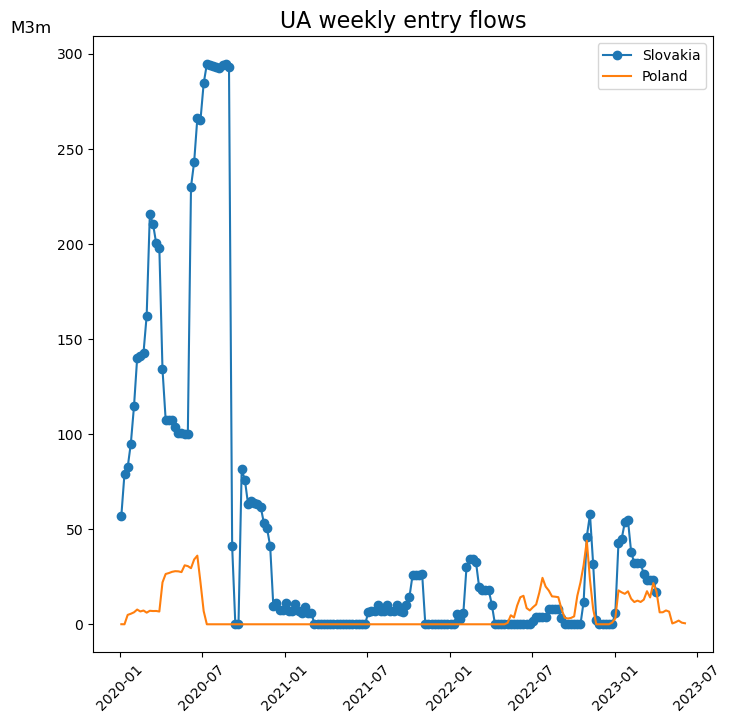

In [91]:
rus = df_e[df_e['[En] Country']=='Russia']['M3m'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)
slov = df_e[df_e['[En] Country']=='Slovakia']['M3m'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)
pol = df_e[df_e['[En] Country']=='Poland']['M3m'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)
rom = df_e[df_e['[En] Country']=='Romania']['M3m'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)
hun = df_e[df_e['[En] Country']=='Hungary']['M3m'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)
mold = df_e[df_e['[En] Country']=='Moldova']['M3m'].groupby(pd.Grouper(freq='W')).sum(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 8))

# ax.plot(rus,color='red',label='Russia',linestyle=':')
ax.plot(slov,label='Slovakia',marker='o')
ax.plot(pol,label='Poland')
# ax.plot(rom,label='Romania')
# ax.plot(hun,label='Hungary')
# ax.plot(mold,label='Moldova')

date_form1 = DateFormatter("%Y-%m")
ax.xaxis.set_major_formatter(date_form1)


plt.xticks(rotation=45)
plt.title('UA weekly entry flows',fontsize='16')
plt.ylabel('M3m',fontsize=12,rotation=0,loc='top')
plt.legend(loc='best')

In [45]:
df[(df['[En] Country']=='Slovakia')&(df['Äàòà / Date']>'2023-01-01')&(df['[EN] Direction']=='Entry')]

,[UA] Êðà¿íà,[En] Country,[UA] Ãðóïà,[En] Group,[UA] Íàçâà â³ðò. òî÷êè,[En] Virtual IP name,[UA] Íàïðÿì,[EN] Direction,Äàòà / Date,Èòîã
1366,Ñëîâà÷÷èíà,Slovakia,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Áóäiíöå (Ñëîâà÷÷èíà),Budince GMS (Slovakia),Âõ³ä,Entry,2023-03-31,3388504.0
1385,Ñëîâà÷÷èíà,Slovakia,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Áóäiíöå (Ñëîâà÷÷èíà),Budince GMS (Slovakia),Âõ³ä,Entry,2023-01-31,7235491.0
1512,Ñëîâà÷÷èíà,Slovakia,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Áóäiíöå (Ñëîâà÷÷èíà),Budince GMS (Slovakia),Âõ³ä,Entry,2023-03-30,3359561.0
1531,Ñëîâà÷÷èíà,Slovakia,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Áóäiíöå (Ñëîâà÷÷èíà),Budince GMS (Slovakia),Âõ³ä,Entry,2023-01-30,7808047.0
1662,Ñëîâà÷÷èíà,Slovakia,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Áóäiíöå (Ñëîâà÷÷èíà),Budince GMS (Slovakia),Âõ³ä,Entry,2023-03-29,3423278.0
...,...,...,...,...,...,...,...,...,...,...
11953,Ñëîâà÷÷èíà,Slovakia,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Áóäiíöå (Ñëîâà÷÷èíà),Budince GMS (Slovakia),Âõ³ä,Entry,2023-03-02,3617739.0
11972,Ñëîâà÷÷èíà,Slovakia,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Áóäiíöå (Ñëîâà÷÷èíà),Budince GMS (Slovakia),Âõ³ä,Entry,2023-02-02,4632510.0
11992,Ñëîâà÷÷èíà,Slovakia,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Áóäiíöå (Ñëîâà÷÷èíà),Budince GMS (Slovakia),Âõ³ä,Entry,2023-01-02,5856165.0
12124,Ñëîâà÷÷èíà,Slovakia,Òðàíñêîðäîíí³ òî÷êè,Cross-border points,ÃÂÑ Áóäiíöå (Ñëîâà÷÷èíà),Budince GMS (Slovakia),Âõ³ä,Entry,2023-03-01,3355781.0


In [15]:
today = date.today()

d1 = '2023-01-01'
# d2 = '2022-12-31'
d2 = today.strftime("%Y-%m-%d")


converter = 10300000   ## KWh to M3m --> 10.3 KWh/m^3
converterTJ = 277778
kwhtwh = 0.000000001

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xe7 in position 2: invalid continuation byte